In [10]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

mu0 = jnp.ones((1,))
cov0 = jnp.ones((1,1))

ts = jnp.linspace(0, 10, 200)

# Define the ODE
def f(t, x):
    return -(1 / 10)**2 * jnp.sin(x)*jnp.cos(x)**3

def g(t, x):
    return 1/10 * jnp.cos(x)**2

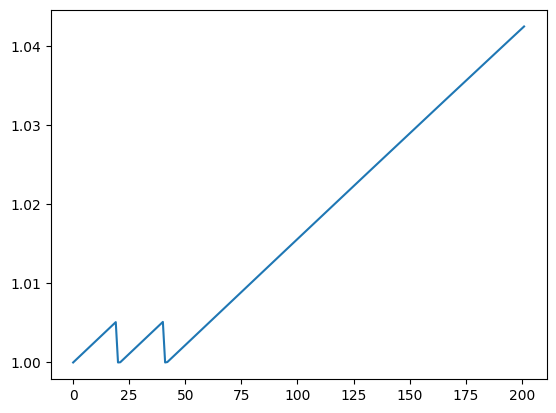

In [19]:
t_o = jnp.arange(1, 3)
y_o = jnp.ones((2,))
R_o = jnp.ones((1,1))
C_o = jnp.ones((1,1))

mu, cov= kalman_filter(f, g, ts, mu0, cov0, t_o, y_o)

plt.plot(mu)

In [18]:
from typing import Callable, Optional, Tuple

from probjax.inference.kalman_filter import *


@partial(jax.jit, static_argnums=(0,1, 8,9))
def kalman_filter(
    drift: Callable,
    diffusion: Callable,
    ts: Array,
    mu0: Array,
    cov0: Array,
    t_o: Optional[Array] = None,
    y_o: Optional[Array] = None,
    C_o: Optional[Array] = None,
    R_o: Optional[Array] = None,
    return_mu_cov_cache: bool = False,
    prediction_method="mfd_linearized",
) -> Tuple[Array, Array, Array, Array]:
    """Kalman filter for a discrete time model on time grid ts.

    Args:
        ts (Array): Time grid to filter on.
        mu0 (Array): Starting mean
        cov0 (Array): Starting covariance
        predict (Callable): Prediction function
        update (Callable): Update function
        t_o (Array): Observation times
        y_o (Array): Observation values
        C_o (Array): Observation projection matrix
        R_o (Array): Observation noise covariance matrix

    Returns:
        Tuple[Array, Array, Array, Array]: Mean and covs at observation times, and mean and covs at all times.
    """

    mu0 = jnp.atleast_1d(mu0)
    cov0 = jnp.atleast_2d(cov0)
    ts = jnp.atleast_1d(ts)
    d = mu0.shape[0]
    dtype = mu0.dtype
    # Check consistent shapes
    assert (
        mu0.shape[0] == cov0.shape[0] == cov0.shape[1]
    ), "Dimension mismatch, cov0 must be a square matrix of shape (d,d) and mu0 must be a vector of shape (d,)"

    # Consistent dtype
    cov0 = cov0.astype(dtype)
    ts = ts.astype(dtype)
    _drift = lambda t, x: jnp.atleast_1d(drift(t, x)).astype(dtype)
    _diffusion = lambda t, x: jnp.atleast_2d(diffusion(t, x)).astype(dtype)

    if t_o is not None and y_o is not None:
        # Merge observation times with time grid
        index = jnp.searchsorted(ts, t_o)
        ts_merged = jnp.insert(ts, index, t_o)
        index = jnp.searchsorted(ts_merged, t_o)

        mask_array = jnp.zeros(len(ts_merged), dtype=jnp.int32)
        index_array = mask_array.at[index].set(1).cumsum()
        num_obs = len(t_o)
    else:
        ts_merged = ts
        index_array = jnp.zeros(len(ts), dtype=jnp.int32)
        t_o = jnp.zeros((1,)) * jnp.nan
        y_o = jnp.zeros((1,)) * jnp.nan
        num_obs = 0


    predict = get_prediction_step(_drift, _diffusion, method="mfd_linearized")
    update = get_update_step(C_o, R_o)

    _identity = lambda mu, cov, *args:  (mu, cov)

    def scan_fun(carry, data):
        mu0, cov0, t0, mu_cache, cov_cache = carry
        t1, j = data
        mu1_, cov1_ = predict(t0, t1, mu0, cov0)
        is_update = t_o[j] == t1
        mu1, cov1 = lax.cond(
            is_update, update, _identity, mu1_, cov1_, t_o[j], y_o[j]
        )
        if return_mu_cov_cache:
            mu_cache, cov_cache = lax.cond(is_update, lambda m,c,j: (m.at[j].set(mu1_), c.at[j].set(cov1_)), lambda m,c,j: (m,c), mu_cache, cov_cache, j)

        return (mu1, cov1, t1, mu_cache, cov_cache), (mu1, cov1)

    init_carry = (mu0, cov0, ts[0], jnp.zeros((num_obs,  d)), jnp.zeros((num_obs, d, d)))
    final_carry, (mus, covs) = lax.scan(
        scan_fun, init_carry, (ts_merged[1:], index_array[:-1])
    )

    mus = jnp.concatenate([mu0[None], mus])
    covs = jnp.concatenate([cov0[None], covs])

    if return_mu_cov_cache:
        return mus, covs, final_carry[-2], final_carry[-1]
    else:
        return mus, covs